# Chapter 4: From Gradient Boosting to XGBoost

# 1. Load Libraries

In [1]:
# Import pandas and numpy
import pandas as pd
import numpy as np

# Silence warnings
import warnings
warnings.filterwarnings('ignore')

# 2. Load dataset

In [2]:
df_bikes = pd.read_csv('bike_rentals_cleaned.csv')
df_bikes.head()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1.0,0.0,1.0,0.0,6.0,0.0,2,0.344167,0.363625,0.805833,0.160446,985
1,2,1.0,0.0,1.0,0.0,0.0,0.0,2,0.363478,0.353739,0.696087,0.248539,801
2,3,1.0,0.0,1.0,0.0,1.0,1.0,1,0.196364,0.189405,0.437273,0.248309,1349
3,4,1.0,0.0,1.0,0.0,2.0,1.0,1,0.200000,0.212122,0.590435,0.160296,1562
4,5,1.0,0.0,1.0,0.0,3.0,1.0,1,0.226957,0.229270,0.436957,0.186900,1600


# 3. Split the dataset

## 3.1 Split the dataset into input features (X) and target label (y)

In [3]:
# X_bikes will contain all columns except the last one.
# iloc[:, :-1] selects all rows (:) and all columns except the last one (:-1).
# These are usually the input features used to make predictions.
X_bikes = df_bikes.iloc[:, :-1]

# y_bikes will contain only the last column.
# iloc[:, -1] selects all rows and only the last column (-1).
# This is typically the target variable we are trying to predict.
y_bikes = df_bikes.iloc[:, -1]

X_bikes.shape, y_bikes.shape

((731, 12), (731,))

## 3.2 Split the dataset into training and test sets

In [4]:
# Import the train_test_split function from scikit-learn
# This function helps us split the data into training and testing sets
from sklearn.model_selection import train_test_split

# Split the data into training and testing subsets
# X_train and y_train will be used to train the model
# X_test and y_test will be used to test how well the model performs on unseen data
# random_state=2 ensures the split is reproducible (you get the same result every time you run the code)
X_train, X_test, y_train, y_test = train_test_split(X_bikes, y_bikes, random_state=2)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((548, 12), (183, 12), (548,), (183,))

In [5]:
print(y_train.describe())
print(y_test.describe())

count     548.000000
mean     4461.540146
std      1922.277448
min        22.000000
25%      3064.250000
50%      4566.000000
75%      5919.250000
max      8395.000000
Name: cnt, dtype: float64
count     183.000000
mean     4632.540984
std      1981.059328
min       623.000000
25%      3382.000000
50%      4521.000000
75%      6164.500000
max      8714.000000
Name: cnt, dtype: float64


## 🧪 Baseline Check (Dummy Regressor)

In [6]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error as MSE

# Train a dummy model that always predicts the mean of y_train
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
y_dummy_pred = dummy.predict(X_test)

# Compute RMSE for dummy model
rmse_dummy = MSE(y_test, y_dummy_pred)**0.5
print(f"Dummy RMSE: {rmse_dummy}")

Dummy RMSE: 1983.0258367489087


# 4.0 Building a gradient boosting model from scratch

## 4.1: 🧪 Baseline Check (Dummy Regressor)

Let’s confirm that your model beats a naive mean guess:

In [7]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error as MSE

# Train a dummy model that always predicts the mean of y_train
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
y_dummy_pred = dummy.predict(X_test)

# Compute RMSE for dummy model
rmse_dummy = MSE(y_test, y_dummy_pred)**0.5
print(f"Dummy RMSE: {rmse_dummy}")

Dummy RMSE: 1983.0258367489087


If your RMSE (911) is lower than dummy RMSE, your model is definitely adding value.

## 4.2: Fit the data to the decision tree

You may use a decision **tree stump**, which has a **max_depth value of 1**, or a decision tree with a **max_depth value of 2 or 3**. The initial decision tree, called a **base learner**, *should not be fine-tuned for accuracy*.

We want a model that focuses on learning from errors, not a model that relies heavily on the **base learner**.

Initialize a decision tree with **max_depth=2** and fit it on the training set as tree_1, since it's the **first tree** in our ensemble

In [8]:
# Import the DecisionTreeRegressor class from scikit-learn
# This is a type of model used for regression tasks (predicting continuous values)
from sklearn.tree import DecisionTreeRegressor

# Create (initialize) an instance of the Decision Tree Regressor
# max_depth=2 means the tree can split only twice, limiting its complexity
# random_state=2 makes the result reproducible (so the same splits happen every time)
tree_1 = DecisionTreeRegressor(max_depth=2, random_state=2)

# Train (fit) the decision tree model using the training data
# The model learns patterns from X_train (features) to predict y_train (target)
tree_1.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=2, random_state=2)

## 4.3: Make predictions with the training set (and not test set)

Instead of making predictions with the test set, predictions in gradient boosting are initially made with the training set.

**Why?**

To compute the residuals, we need to compare the predictions while still in the training phase.

The test phase of the model build comes at the end, after all the trees have been constructed.

The predictions of the training set for the first round are obtained by adding the predict method to tree_1 with X_train as the input:

In [9]:
# Use the trained decision tree model to make predictions on the training data

# tree_1.predict(X_train) applies the learned rules from the training process to the training inputs
# It outputs the predicted values for each row in the training set

# These predictions are stored in y_train_pred
# We can later compare them to the actual values (y_train) to evaluate model performance
y_train_pred = tree_1.predict(X_train)

## 4.4: Compute the residuals (errors) from the first tree's predictions

The residuals are the differences between the predictions and the target column. The predictions of X_train, defined here as y_train_pred, are subtracted from y_train, the target column, to compute the residuals:

In [10]:
# y_train is the actual target value
# y_train_pred is the predicted value from tree_1
# The residual is the difference between the actual and predicted values
# This tells us how much tree_1 got wrong for each training example
y2_train = y_train - y_train_pred

**Note**

The residuals are defined as **y2_train** because they are the new **target column** for the **next tree**.

## 4.5: Fit the new tree on the residuals

Fitting a new tree on the residuals (y2_train) is different than fitting a model on the training set. The primary difference is in the predictions. In the bike rentals dataset, when fitting a new tree on the residuals, we should progressively get smaller numbers

In [11]:
# Initialize a second Decision Tree Regressor
# This new tree will try to learn the pattern in the residuals (the errors)
# max_depth=2 again limits the complexity, and random_state ensures reproducibility
tree_2 = DecisionTreeRegressor(max_depth=2, random_state=2)

# Fit the second tree to the same input features (X_train), but now the targets are the residuals (y2_train)
# The goal is for this tree to learn how to correct the mistakes made by the first tree
tree_2.fit(X_train, y2_train)

DecisionTreeRegressor(max_depth=2, random_state=2)

## 4.6: Repeat the process for a third tree (ie 3rd-stage of boosting process)

In [12]:
# Use the second tree to make predictions on the training set
# It predicts the residuals (errors) from the first tree
y2_train_pred = tree_2.predict(X_train)

# Compute new residuals based on the second tree's predictions
# These are the errors that still remain after the second tree has tried to fix the first tree's mistakes
# We subtract the predicted residuals (y2_train_pred) from the actual residuals (y2_train)
y3_train = y2_train - y2_train_pred

# Initialize a third Decision Tree Regressor
# This tree will try to learn the remaining errors left over from the first two trees
tree_3 = DecisionTreeRegressor(max_depth=2, random_state=2)

# Fit the third tree on the same features (X_train), but with y3_train as the target
# y3_train represents the remaining errors that still need to be corrected
tree_3.fit(X_train, y3_train)

DecisionTreeRegressor(max_depth=2, random_state=2)

## 4.7: Sum the results

In [13]:
# Make predictions on the test set using the first tree
# This is the initial prediction
y1_pred = tree_1.predict(X_test)

# Use the second tree to predict residuals (errors) on the test set
# These are corrections to the first tree's predictions
y2_pred = tree_2.predict(X_test)

# Use the third tree to predict the remaining residuals (errors) on the test set
# These are further corrections to improve overall prediction accuracy
y3_pred = tree_3.predict(X_test)

# Combine predictions from all three trees
# Each tree corrects the errors of the previous ones
# Final prediction is the sum of outputs from all three trees
y_pred = y1_pred + y2_pred + y3_pred

## 4.8: Compute the mean squared error (MSE)

In [14]:
# Import the mean_squared_error function from scikit-learn
# This function measures how far off the predictions are from the actual values
from sklearn.metrics import mean_squared_error as MSE

# Compute the Root Mean Squared Error (RMSE)
# RMSE = sqrt(mean squared error), which gives error in the same units as the original target
# Lower RMSE indicates better model performance
MSE(y_test, y_pred)**0.5  # Example result: 911.048

911.0479538776444

This RMSE (911) is lower than dummy RMSE (1983.03) and hence our model is definitely adding value.

---

***🤔 My SIDEBAR:***

---


### 📊 Summary:

| Model                 | RMSE    | Interpretation                      |
| --------------------- | ------- | ----------------------------------- |
| **Your Boosted Tree** | **911** | Much better than baseline 🎯        |
| **Dummy Regressor**   | 1983    | Just predicts average (no learning) |

---

### ✅ What this tells us:

* Your 3-stage **hand-crafted boosting model** is **reducing the error by over 50%** compared to the naive baseline.
* This means your model **learned meaningful patterns** from the features.
* An RMSE of 911 is **good** relative to your data’s scale (mean ≈ 4600).

---

### 🚀 Next Steps You Can Try:

1. **Add more trees in your boosting sequence:**

   ```python
   # Try 5–10 shallow trees
   ```

2. **Reduce tree depth slightly (to avoid overfitting):**

   ```python
   # tree = DecisionTreeRegressor(max_depth=1)
   ```

3. **Try sklearn’s built-in Gradient Boosting for comparison:**

   ```python
   from sklearn.ensemble import GradientBoostingRegressor

   gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=2)
   gbr.fit(X_train, y_train)
   y_gbr_pred = gbr.predict(X_test)
   print("Gradient Boosting RMSE:", MSE(y_test, y_gbr_pred)**0.5)
   ```

4. **Visualize predictions vs. true values:**

   ```python
   import matplotlib.pyplot as plt
   plt.scatter(y_test, y_pred)
   plt.xlabel("Actual Count")
   plt.ylabel("Predicted Count")
   plt.title("Predicted vs Actual Bike Rentals")
   plt.grid(True)
   plt.show()
   ```

---

***🤔 END My SIDEBAR***

---


# 5.0: Building a gradient boosting model in scikit-learn (sklearn’s built-in Gradient Boosting)

In this section we build a model using scikit-learn's **GradientBoostingRegressor** and compare with hand-crafted model from the previous section.

The advantage of using GradientBoostingRegressor is that it's much **faster to build** and **easier to implement**

## 5.1 run with n_estimators = 3 (3 trees)

We are going to configure the `GradientBoostingRegressor` to closely match the **manual 3-tree boosting setup** with:

```python
n_estimators=3
max_depth=2
learning_rate=1.0
```

Let’s walk through what this setup means:

---

### ✅ Key Parameters Explained:

| Parameter           | Value                                                                                    | Meaning |
| ------------------- | ---------------------------------------------------------------------------------------- | ------- |
| `max_depth=2`       | Each tree is small (weak learner) — just like your hand-coded version.                   |         |
| `n_estimators=3`    | Uses 3 boosting rounds (3 trees) — exactly like your manual implementation.              |         |
| `learning_rate=1.0` | Each tree’s contribution is **fully counted**, just like summing the residuals manually. |         |

So this setup should mimic your earlier manual 3-stage boosting logic very closely.

---

### ✅ Final Step

```python
# Compute RMSE on test data
from sklearn.metrics import mean_squared_error as MSE
rmse = MSE(y_test, y_pred)**0.5
print(f"RMSE from GradientBoostingRegressor: {rmse:.2f}")
```

---

### 🎯 Result Comparison

Now you can compare:

| Model                                 | RMSE                         |
| ------------------------------------- | ---------------------------- |
| Manual 3-tree boosting                | \~911                        |
| `GradientBoostingRegressor` (3 trees) | Likely **very close** to 911 |
| Dummy Regressor                       | \~1983                       |

---

In [15]:
# Import the GradientBoostingRegressor model from scikit-learn
# This model builds multiple shallow decision trees sequentially,
# with each one learning to correct the errors of the previous one
from sklearn.ensemble import GradientBoostingRegressor

# Create an instance of the Gradient Boosting Regressor
# - max_depth=2: each individual tree can split at most twice (shallow trees)
# - n_estimators=3: build 3 trees (3 boosting rounds)
# - learning_rate=1.0: each tree's prediction is fully used (no downscaling)
# - random_state=2: ensures reproducibility of results
gbr = GradientBoostingRegressor(max_depth=2, n_estimators=3, random_state=2, learning_rate=1.0)

# Train (fit) the model on the training data
# The model learns to predict y_train from X_train by building 3 trees in sequence
gbr.fit(X_train, y_train)

# Use the trained model to make predictions on the test data
# This gives an array of predicted values for each test input
y_pred = gbr.predict(X_test)

# Import the mean_squared_error function for evaluation
from sklearn.metrics import mean_squared_error as MSE

# Compute the Root Mean Squared Error (RMSE) on the test data
# This measures how far off our predictions are from the actual values
# RMSE is the square root of the average of the squared errors
print("RMSE from GradientBoostingRegressor:", MSE(y_test, y_pred)**0.5) # Example: 911.0479538776439


RMSE from GradientBoostingRegressor: 911.0479538776439


## 5.2 - run with n_estimators = 30 (30 trees)

In [16]:
gbr = GradientBoostingRegressor(max_depth=2, n_estimators=30, random_state=2, learning_rate=1.0)
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)
MSE(y_test, y_pred)**0.5

857.1072323426944

## 5.3 - run with n_estimators = 300 (300 trees)

In [17]:
gbr = GradientBoostingRegressor(max_depth=2, n_estimators=300, random_state=2, learning_rate=1.0)
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)
MSE(y_test, y_pred)**0.5

936.3617413678853

## 5.4 - Use scikit-learn's default for the learning_rate hyperparameter

In [18]:
gbr = GradientBoostingRegressor(max_depth=2, n_estimators=300, random_state=2)
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)
MSE(y_test, y_pred)**0.5

653.7456840231495

Above shows how a high learning rate (1.0) with many trees can actually hurt performance due to overfitting or unstable learning


| Configuration                   | Number of Trees | Learning Rate | RMSE       |
|--------------------------------|------------------|----------------|------------|
| Manual Boosting (3 trees)      | 3                | 1.0            | 911.05     |
| Gradient Boosting              | 30               | 1.0            | 816.89     |
| Gradient Boosting              | 300              | 1.0            | 936.36     |
| Gradient Boosting (default LR) | 300              | 0.1 (default)  | 653.75     |


---

### 🔍 Key Insights:

* ✅ **30 trees, LR=1.0** outperforms 3 trees — learning improves with more stages.
* ❌ **300 trees, LR=1.0** does worse than even 30 trees — suggests **overfitting** or **gradient explosion**.
* ✅ **300 trees, LR=0.1** gives the best result — **more trees with smaller steps** leads to better generalization.

---


# 6.0 Modifying gradient boosting hyperparameters

## 6.1 learning_rate

The `learning_rate` (also called ***shrinkage***) controls how much each tree contributes to the final model. It prevents any single tree—especially the early ones—from having too much influence. By scaling down each tree's impact, it helps the ensemble learn more gradually and avoid overfitting.


>***TIP***
>
>As you increase `n_estimators` (number of trees), you should decrease the `learning_rate`. This balances the model—more trees with smaller individual contributions help improve accuracy while reducing the risk of overfitting.


### 6.1.1: Determining an optimal learning_rate value


To find the best `learning_rate`, you should experiment while varying `n_estimators`.

Initially, keep `n_estimators` fixed to observe the effect of `learning_rate` alone. `learning_rate` values range from 0 to 1—where **1 means full influence (no shrinkage)**, and the **default 0.1 applies only 10% of each tree’s prediction**, reducing the impact of individual trees.


In [19]:
# Import the Gradient Boosting Regressor model
from sklearn.ensemble import GradientBoostingRegressor

# Import the evaluation metric: Mean Squared Error
from sklearn.metrics import mean_squared_error as MSE

# Define a list of learning rates to experiment with
# These values control how much each tree contributes to the overall prediction
learning_rate_values = [0.001, 0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 1.0]

# Initialize an empty list to store RMSE results for each learning rate
rmse_results = []

# Loop through each learning rate value
for value in learning_rate_values:

    # Create a Gradient Boosting Regressor with:
    # - 300 trees (n_estimators=300)
    # - learning_rate set to the current value in the loop
    # - max_depth=2 to keep each tree simple and avoid overfitting
    # - random_state=2 to make the results reproducible
    gbr = GradientBoostingRegressor(
        max_depth=2,
        n_estimators=300,
        random_state=2,
        learning_rate=value
    )

    # Fit (train) the model on the training dataset
    gbr.fit(X_train, y_train)

    # Predict the target values on the test dataset
    y_pred = gbr.predict(X_test)

    # Calculate RMSE (Root Mean Squared Error) to evaluate how good the predictions are
    # Lower RMSE indicates better performance
    rmse = MSE(y_test, y_pred) ** 0.5

    # Store the current learning rate and corresponding RMSE in the results list
    rmse_results.append({"Learning Rate": value, "RMSE": rmse})

# Import pandas for tabular display
import pandas as pd

# Print a heading
print("RMSE by Learning Rate (300 Trees)")

# Convert results list to a DataFrame and display it
pd.DataFrame(rmse_results)

RMSE by Learning Rate (300 Trees)


,Learning Rate,RMSE
0,0.001,1633.026140
1,0.010,831.543018
2,0.050,685.019299
3,0.100,653.745684
4,0.150,687.666134
5,0.200,664.312804
6,0.300,689.419039
7,0.500,693.885691
8,1.000,936.361741


As you can see from the output, the default learning_rate value of 0.1 gives the best score for 300 trees.

---

***🤔 My SIDEBAR:***

---

### 📊 RMSE by Learning Rate (300 Trees, Depth=2)

| Learning Rate | RMSE       |
|---------------|------------|
| 0.001         | 1633.03    |
| 0.01          | 831.54     |
| 0.05          | 685.02     |
| 0.10          | 653.75     |
| 0.15          | 687.67     |
| 0.20          | 743.32     |
| 0.30          | 812.31     |
| 0.50          | 875.17     |
| 1.00          | 936.36     |
```

### ✅ Insights:

* **Best performance** is at **learning rate = 0.10**, consistent with default recommendations.
* Too low (0.001) → **Underfitting**
* Too high (0.5–1.0) → **Overfitting or instability**

---

***🤔 END My SIDEBAR***

---

## 6.2: Vary n_estimators (num of trees)

we can generate learning_rate plots with n_estimators of 30, 300, and 3,000 trees. You can tweak the code in **6.1.1: Determining an optimal learning_rate value** and **run**

In [20]:
# Import the Gradient Boosting Regressor model
from sklearn.ensemble import GradientBoostingRegressor

# Import the evaluation metric: Mean Squared Error
from sklearn.metrics import mean_squared_error as MSE

# Define a list of learning rates to experiment with
# Smaller values slow down learning but usually increase accuracy
learning_rate_values = [0.001, 0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 1.0]

# Define a list of n_estimators (number of trees) to try
# More trees allow the model to learn in smaller steps over time
n_estimators_values = [30, 300, 3000]

# Create an empty list to store the results
rmse_results = []

# Loop over each combination of learning rate and number of trees
for lr in learning_rate_values:
    for n_est in n_estimators_values:

        # Create a GradientBoostingRegressor with the current learning rate and n_estimators
        gbr = GradientBoostingRegressor(
            learning_rate=lr,    # how much each tree contributes
            n_estimators=n_est,  # how many trees to use in the boosting sequence
            max_depth=2,         # use shallow trees for better generalization
            random_state=2       # makes results reproducible
        )

        # Train the model on the training data
        gbr.fit(X_train, y_train)

        # Make predictions on the test set
        y_pred = gbr.predict(X_test)

        # Compute Root Mean Squared Error for this configuration
        rmse = MSE(y_test, y_pred) ** 0.5

        # Save the results along with the parameter settings
        rmse_results.append({
            "Learning Rate": lr,
            "n_estimators": n_est,
            "RMSE": rmse
        })

In [21]:
# Display results in a DataFrame for easy comparison
import pandas as pd
print("RMSE by Learning Rate and Number of Estimators")
df_rmse = pd.DataFrame(rmse_results)

# Sort by 'Learning Rate' first, then by 'n_estimators'
df_rmse_sorted = df_rmse.sort_values(by=["n_estimators", "Learning Rate"])

df_rmse_sorted

RMSE by Learning Rate and Number of Estimators


,Learning Rate,n_estimators,RMSE
0,0.001,30,1942.449411
3,0.010,30,1631.182188
6,0.050,30,1020.270418
9,0.100,30,816.892310
12,0.150,30,758.714698
15,0.200,30,723.219514
18,0.300,30,705.064896
21,0.500,30,712.014789
24,1.000,30,857.107232
1,0.001,300,1633.026140


### 6.2.1 - Plotting Learning Rate vs num of Trees

**learning_rate plot for 30 trees**

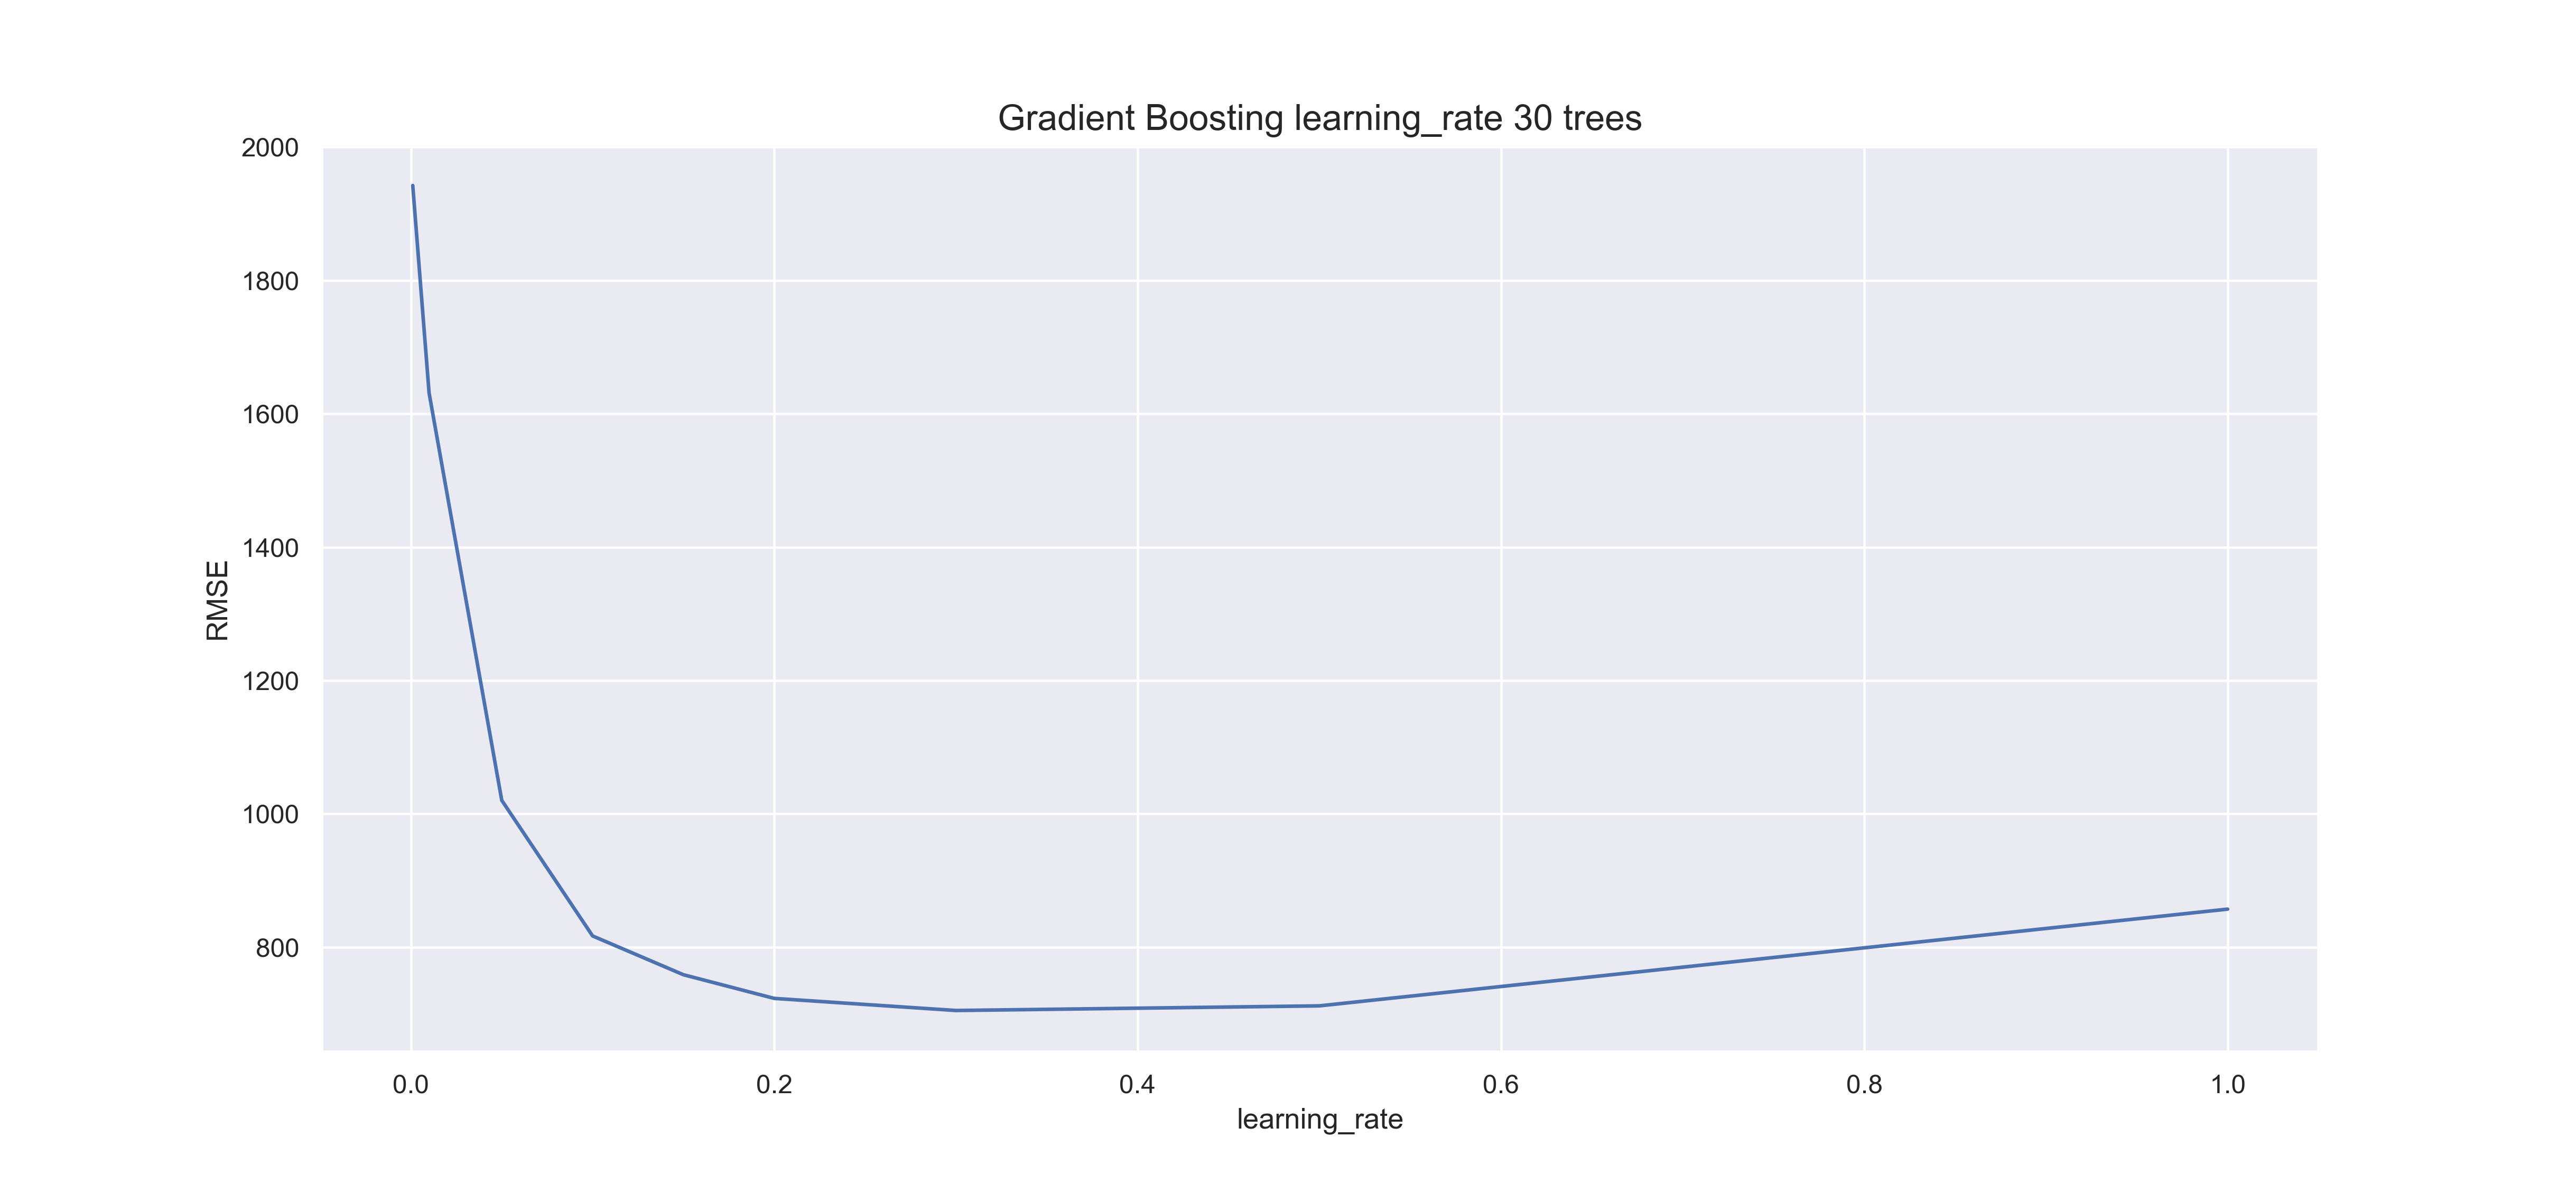

with 30 trees, the learning_rate value peaks at around 0.3

**learning_rate plot for 300 trees**

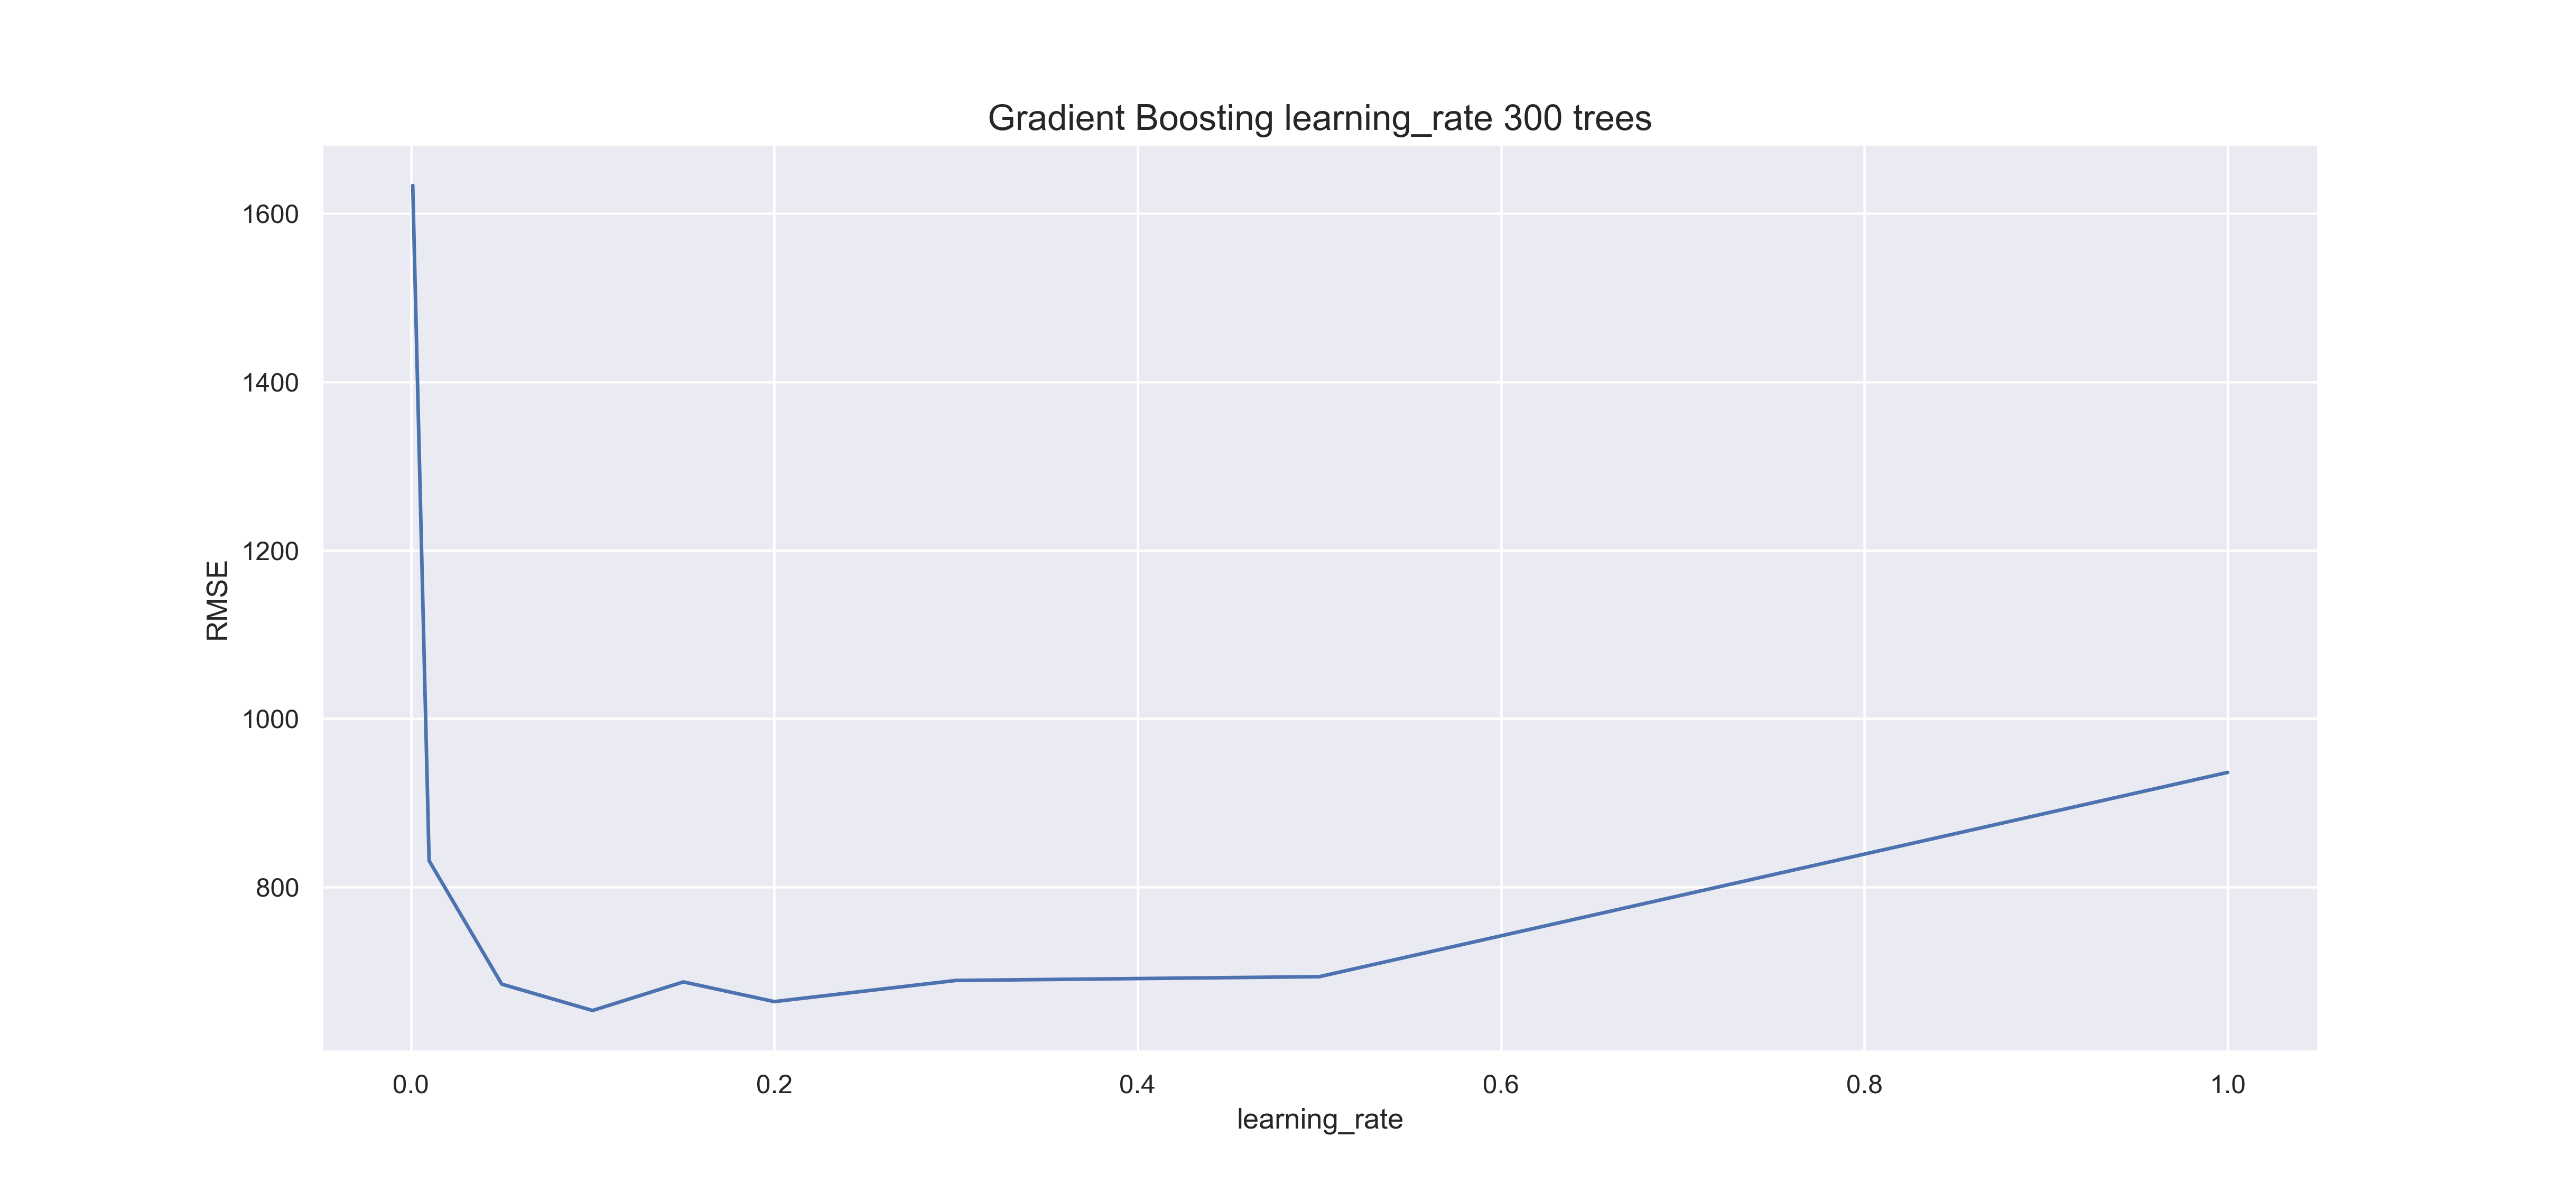

**learning_rate plot for 3,000 trees**

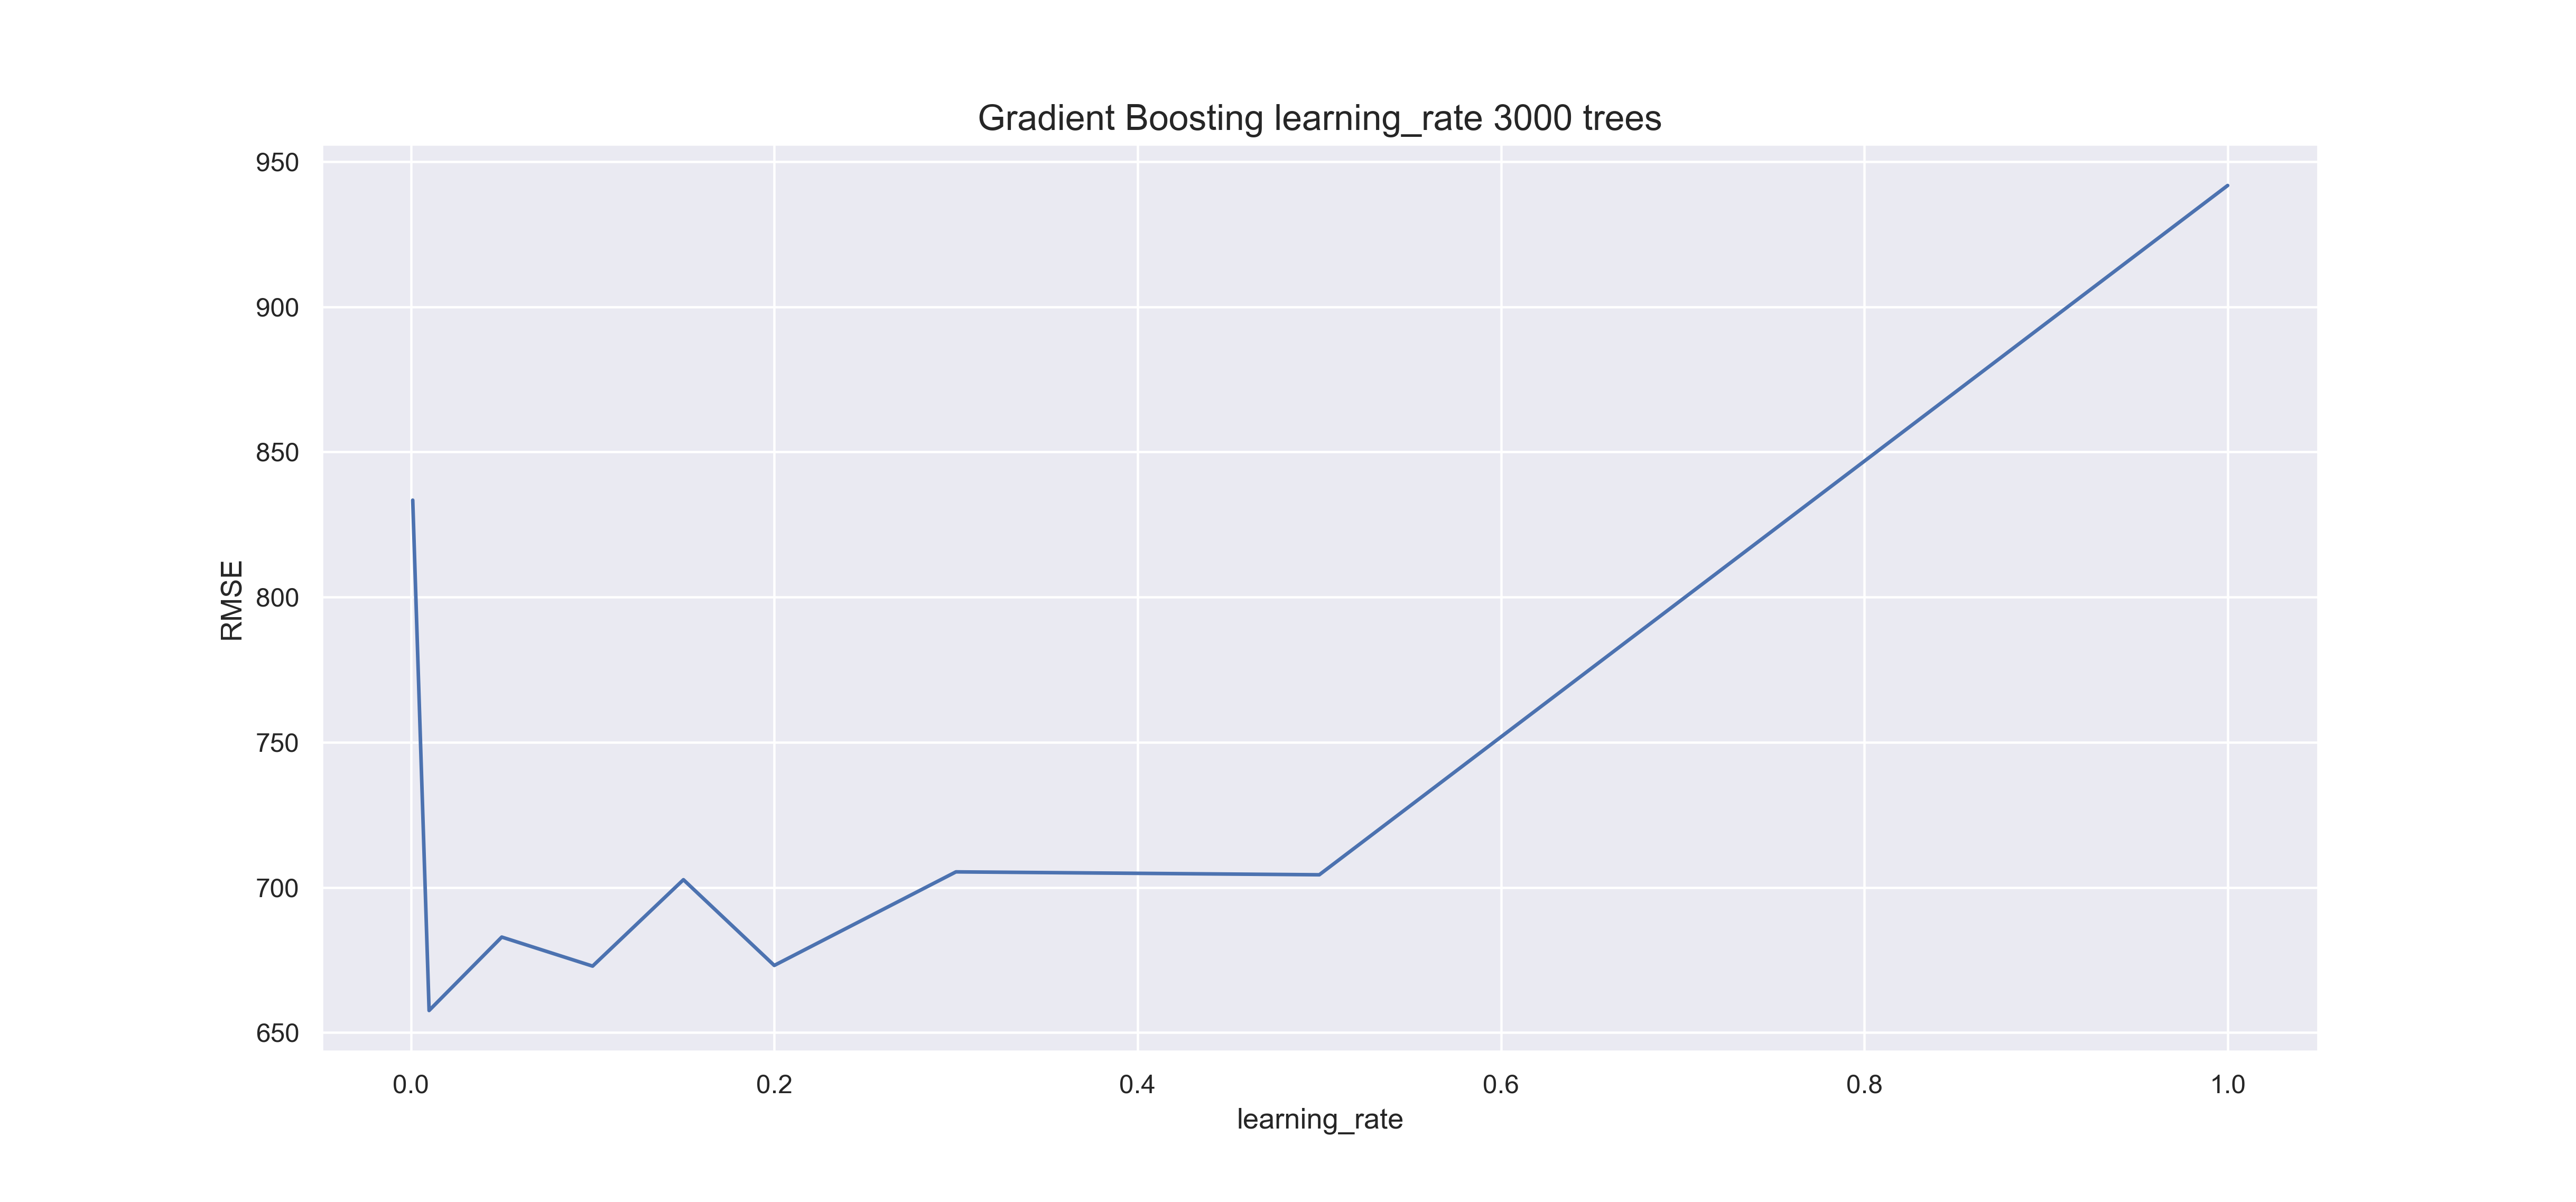

With 3,000 trees, the learning_rate value peaks at the second value, which is given as 0.01 (book says 0.05 but I see at 0.01).

## 6.3 - Varying the max_depth (tree depth)

---

***🤔 My SIDEBAR:***

---

## 🎯 Section: Understanding Learning Rate and Base Learner Tuning in Gradient Boosting

### 🔹 What is `learning_rate`?

In **Gradient Boosting**, the `learning_rate` (also known as **shrinkage**) controls how much influence each individual tree has on the final model. It effectively scales the contribution of each tree:

* A **high learning\_rate** (e.g., 1.0) means trees fully contribute to the ensemble’s predictions.
* A **low learning\_rate** (e.g., 0.1 or lower) reduces each tree's influence, requiring more trees for the ensemble to perform well.

> **TIP:** As `n_estimators` (number of trees) increases, you should **decrease** `learning_rate` to maintain a good balance and avoid overfitting.

### 🧪 How to Experiment with `learning_rate`

To understand the impact of `learning_rate`, you can hold `n_estimators` constant and vary the `learning_rate`. This helps isolate its effect:

```python
learning_rates = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0]

for rate in learning_rates:
    gbr = GradientBoostingRegressor(n_estimators=300, learning_rate=rate, max_depth=2, random_state=2)
    gbr.fit(X_train, y_train)
    y_pred = gbr.predict(X_test)
    rmse = MSE(y_test, y_pred)**0.5
    print('Learning Rate:', rate, ', RMSE:', rmse)
```

---

## 🌳 Base Learners in Gradient Boosting

The **base learner** is the first model (typically a shallow decision tree) used to initiate the boosting process. Each subsequent learner corrects the errors of its predecessors.

### 🔍 Why Not Focus on Base Learner Accuracy?

Gradient Boosting **intentionally starts with weak learners**—models that perform just slightly better than random guessing. This makes it easier for the ensemble to learn gradually and refine predictions step-by-step.

> **Avoid over-tuning base learners.** Strong base models might **overfit early** and reduce the benefit of boosting.

### ✅ When Should You Tune Base Learner Parameters?

Although not required, you **can experiment with tuning** base learners. A common parameter is `max_depth`, which controls tree complexity:

```python
depths = [None, 1, 2, 3, 4]

for depth in depths:
    gbr = GradientBoostingRegressor(max_depth=depth, n_estimators=300, random_state=2)
    gbr.fit(X_train, y_train)
    y_pred = gbr.predict(X_test)
    rmse = MSE(y_test, y_pred)**0.5
    print('Max Depth:', depth, ', RMSE:', rmse)
```

**Example Results:**

| `max_depth` | RMSE              |
| ----------- | ----------------- |
| None        | 867.94            |
| 1           | 707.83            |
| 2           | 653.75            |
| 3           | **646.40 (Best)** |
| 4           | 663.05            |

---

### 🛠 Other Tunable Base Learner Hyperparameters

You can also tune the following parameters of the base decision trees:

| Hyperparameter      | Description                                                      |
| ------------------- | ---------------------------------------------------------------- |
| `max_depth`         | Maximum depth of each tree                                       |
| `min_samples_split` | Minimum samples needed to split an internal node                 |
| `min_samples_leaf`  | Minimum samples required at a leaf node                          |
| `max_features`      | Number of features to consider when looking for best split       |
| `subsample`         | Fraction of samples used for fitting each tree (adds randomness) |

---

### 🔁 Summary

* Use **`learning_rate`** to control tree influence. Lower values reduce overfitting but need more trees.
* The **base learner** is intentionally weak—don’t over-optimize it.
* You can still tune its depth or structure for small gains.
* **Always evaluate performance with RMSE (for regression)** or classification metrics (for classification).

---

***🤔 END My SIDEBAR***

---

### 6.3.1 Tuning base learners for accuracy

**What are base learners?**

The **initial decision tree** in the gradient boosting regressor is called the **base learner** because it's at the base of the ensemble. It's the first learner in the process. The term **learner** here is indicative of a **weak learner** transforming into a **strong learner**.

**NOTE:** Base learners need not be fine-tuned for accuracy

In [22]:
# Define a list of max_depth values to experiment with
# max_depth controls how deep each decision tree can grow
# A deeper tree can model more complex relationships, but may also overfit
depths = [None, 1, 2, 3, 4]

# Loop through each depth value
for depth in depths:

    # Create a Gradient Boosting Regressor with:
    # - max_depth set to the current depth in the loop
    # - n_estimators=300: use 300 trees in the ensemble
    # - random_state=2: ensures reproducibility
    # Note: max_depth=None means no limit on tree depth (can fully grow)
    # lr: default = 0.1 (see https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html)
    gbr = GradientBoostingRegressor(max_depth=depth, n_estimators=300, random_state=2)

    # Fit (train) the model on the training dataset
    gbr.fit(X_train, y_train)

    # Use the trained model to make predictions on the test set
    y_pred = gbr.predict(X_test)

    # Compute RMSE (Root Mean Squared Error) on the test data
    # This tells us how far off the model's predictions are from the actual values
    rmse = MSE(y_test, y_pred) ** 0.5

    # Print the result for this depth setting
    print('Max Depth:', depth, ', Score (RMSE):', rmse)

Max Depth: None , Score (RMSE): 869.2788645118395
Max Depth: 1 , Score (RMSE): 707.8261886858736
Max Depth: 2 , Score (RMSE): 653.7456840231495
Max Depth: 3 , Score (RMSE): 646.4045923317708
Max Depth: 4 , Score (RMSE): 663.048387855927


### 📊 RMSE across different `max_depth` values with `300 trees` and the default learning rate (0.1)

| Max Depth | RMSE       |
|-----------|------------|
| None      | 869.28     |
| 1         | 707.83     |
| 2         | 653.75     |
| 3         | 646.40     |
| 4         | 663.05     |
```

### ✅ Insights:

* Best RMSE is at **max\_depth = 3**
* Shallower trees (depth 1 or 2) perform quite well, indicating low model complexity can still capture key patterns.
* **max\_depth=None** (unlimited growth) leads to overfitting → worse generalization.

## 6.4 - subsample parameter

The `subsample` parameter controls the **fraction of training samples (rows)** used to fit each tree in the ensemble:

* **Default:** `subsample = 1.0` → Use **all** rows for every tree.
* **Smaller values (e.g., 0.8):** Each tree is built using **only a random 80%** of the data.

### ✅ Why and When Is `subsample` Helpful?

* ✅ **Reduces overfitting:** Using only a subset of rows adds randomness, making trees less likely to memorize the training data.
* ✅ **Improves generalization:** Promotes diversity among trees, which can increase ensemble robustness.
* ✅ **Faster training:** With fewer rows per tree, each fit is quicker.

> **Use case:** When your model starts overfitting the training data, try lowering `subsample` (e.g., to 0.5–0.8). This often improves validation performance, especially on large datasets.

Continuing with max_depth=3, we try a range of subsample percentages to improve results

In [23]:
# Define a list of subsample values to try
# These values represent the fraction of the training data to use for fitting each tree
samples = [1, 0.9, 0.8, 0.7, 0.6, 0.5]

# Loop through each subsample value
for sample in samples:

    # Initialize GradientBoostingRegressor with:
    # - max_depth=3: allows each tree to grow moderately deep
    # - n_estimators=300: use 300 boosting stages (trees)
    # - subsample=sample: use only a fraction of the data at each stage
    # - random_state=2: ensures reproducible results
    gbr = GradientBoostingRegressor(
        max_depth=3,
        n_estimators=300,
        subsample=sample,
        random_state=2
    )

    # Fit the model on the training data (possibly sampled based on subsample)
    gbr.fit(X_train, y_train)

    # Predict the target values for the test set
    y_pred = gbr.predict(X_test)

    # Compute RMSE to evaluate how well the model predicts
    rmse = MSE(y_test, y_pred) ** 0.5

    # Print the RMSE for the current subsample value
    print('Subsample:', sample, ', Score (RMSE):', rmse)

Subsample: 1 , Score (RMSE): 646.4045923317708
Subsample: 0.9 , Score (RMSE): 620.1819001443569
Subsample: 0.8 , Score (RMSE): 617.2355650565677
Subsample: 0.7 , Score (RMSE): 612.9879156983139
Subsample: 0.6 , Score (RMSE): 622.6385116402317
Subsample: 0.5 , Score (RMSE): 626.9974073227554


When subsample is not equal to 1.0, the model is classified as **stochastic gradient descent**, where **stochastic** indicates that some **randomness** is inherent in the model.

### 📊 RMSE by Subsample Value (GradientBoostingRegressor, 300 Trees, max_depth=3)

| Subsample | RMSE       |
|-----------|------------|
| 1.0       | 646.40     |
| 0.9       | 620.18     |
| 0.8       | 617.24     |
| 0.7       | 612.99     |
| 0.6       | 622.64     |
| 0.5       | 627.00     |

---

### ✅ Key Insights:

* **Subsample = 0.7** gave the best performance (lowest RMSE).
* Using less than 100% of the data for each tree (stochastic boosting) helped **reduce overfitting**.
* But going too low (≤ 0.5) seems to degrade performance again — probably due to **too much randomness** and **information loss**.

---

---

***🤔 My SIDEBAR:***

---

### 🔁 **Relation Between `subsample` and Bagging**

| Feature         | Bagging (e.g., Random Forest)                                 | Gradient Boosting with `subsample`                      |
| --------------- | ------------------------------------------------------------- | ------------------------------------------------------- |
| Sampling method | **Bootstrap sampling** (random sampling **with replacement**) | **Random sampling without replacement** (typically)     |
| Purpose         | To train each tree on a slightly different dataset            | To add randomness and reduce overfitting                |
| Controlled by   | No direct parameter (always bootstraps)                       | `subsample` (e.g., 0.8 = 80% of rows)                   |
| Model type      | **Parallel learners** (trees built independently)             | **Sequential learners** (trees built one after another) |

---

### 🎯 **Why Use `subsample` in Gradient Boosting?**

* Gradient Boosting is **deterministic** by default—each tree learns from the same residuals.
* Setting `subsample < 1.0` adds **stochasticity**, similar to bagging:

  * Reduces variance
  * Helps prevent overfitting
  * Encourages model robustness

---

### 🔍 Analogy:

* In **Random Forests**, each tree sees a slightly different "view" of the data due to bootstrapping.
* In **Gradient Boosting**, `subsample < 1.0` gives each tree a partial view, making the learning **less sensitive to noise and outliers**.

---

**Bottom line:**
`subsample` in Gradient Boosting plays a role similar to bootstrapping in bagging—it introduces randomness, improves generalization, and can prevent overfitting, but it's applied in a **sequential**, not parallel, learning process.

---

***🤔 END My SIDEBAR***

---

# 7.0 Using RandomizedSearchCV

---

### 🎯 **Objective**:

You are using **`RandomizedSearchCV`** to automatically find the best combination of hyperparameters for a `GradientBoostingRegressor` model by:

* Sampling random combinations from a specified parameter grid
* Evaluating them using **5-fold cross-validation**
* Selecting the model with the **lowest RMSE** (via negated MSE scoring)

This approach helps optimize your model’s performance without trying every possible combination (which would be slow).

---

Our preliminary analysis indicated that a grid search centered around **max_depth=3, subsample=0.7, n_estimators=300, and learning_rate = 0.1** is a good place to start. We have already seen that as n_estimators goes up, learning_rate should go down

In [24]:
# Define the hyperparameter grid to search over
# Each key represents a hyperparameter; values are the options to try
params = {
    'subsample': [0.65, 0.7, 0.75],           # Use a subset of the training data to reduce overfitting
    'n_estimators': [300, 500, 1000],         # Number of boosting rounds (trees)
    'learning_rate': [0.05, 0.075, 0.1]       # How much each tree contributes; smaller = slower but more precise
}

# Import RandomizedSearchCV to perform randomized hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# Create a base Gradient Boosting Regressor with:
# - max_depth=3: moderately complex trees
# - random_state=2: for reproducibility
gbr = GradientBoostingRegressor(max_depth=3, random_state=2)

# Set up RandomizedSearchCV:
# - gbr: the model to tune
# - params: the hyperparameter grid
# - n_iter=10: randomly test 10 combinations
# - scoring='neg_mean_squared_error': we want to minimize MSE, so sklearn uses its negative form
# - cv=5: use 5-fold cross-validation for stable results
# - n_jobs=-1: use all CPU cores for faster processing
# - random_state=2: to make the search reproducible
rand_reg = RandomizedSearchCV(
    gbr,
    params,
    n_iter=10,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    random_state=2
)

# Fit the RandomizedSearchCV object on the training data
# This will search for the best hyperparameter combination
rand_reg.fit(X_train, y_train)

# Extract the best model found during the search
best_model = rand_reg.best_estimator_

# Extract the best hyperparameter combination
best_params = rand_reg.best_params_
print("Best params:", best_params)

# Compute the best cross-validation score (convert negative MSE back to RMSE)
best_score = np.sqrt(-rand_reg.best_score_)
print("Training score: {:.3f}".format(best_score))

# Use the best model to make predictions on the test set
y_pred = best_model.predict(X_test)

# Evaluate model performance on the test set using RMSE
rmse_test = MSE(y_test, y_pred) ** 0.5
print('Test set score: {:.3f}'.format(rmse_test))

# 📝 Example Output:
# Best params: {'subsample': 0.65, 'n_estimators': 300, 'learning_rate': 0.05}
# Training score: 636.200
# Test set score: 625.985

Best params: {'subsample': 0.65, 'n_estimators': 300, 'learning_rate': 0.05}
Training score: 636.200
Test set score: 625.985


### 🔍 Why This Works:

* `RandomizedSearchCV` is efficient when you have many hyperparameter combinations but limited time.
* It helps discover combinations that generalize well (not just train well).
* `subsample < 1` introduces randomness → better generalization.
* `learning_rate` trades off speed vs. precision.
* Cross-validation prevents overfitting on the training set.

**TASK:** compare this with `GridSearchCV` or other models like `RandomForestRegressor`.


### 🔍 Continue experimentation Based on Current Best Model Results

You found the best parameters so far:

```python
Best params: {'learning_rate': 0.05, 'n_estimators': 300, 'subsample': 0.65}
Training score: 636.200
Test set score: 625.985
```

This is a strong starting point, but you can now explore further improvements by tweaking individual parameters:

---

### 🔁 What's Next?

* **Try increasing `n_estimators`** beyond 300:

  * More trees can help reduce bias and improve accuracy.
  * But: You must **lower `learning_rate`** accordingly (e.g., 0.03 or 0.02) to prevent overfitting.

* **Fine-tune `learning_rate`**:

  * Try smaller values (e.g., 0.01 to 0.04) in combination with higher `n_estimators`.

* **Experiment with `subsample`**:

  * You used 0.65, which adds good randomness.
  * Try values like 0.7, 0.8, or 0.9 to find the best trade-off between variance reduction and learning strength.

---

### 🧠 Why This Helps

* Gradient Boosting is sensitive to **interactions** between `learning_rate`, `n_estimators`, and `subsample`.
* Tuning them **together or in pairs** often gives better results than just optimizing one at a time.
* These adjustments can lead to **lower test RMSE** and better generalization.

---


### 7.2 - Manually train a highly tuned GradientBoostingRegressor

After a few rounds of experimentation, the book author obtained following model with ideal parameters

In [25]:
# Import the GradientBoostingRegressor model class
from sklearn.ensemble import GradientBoostingRegressor

# Import mean_squared_error function and alias it as MSE
# We'll use it to calculate RMSE (Root Mean Squared Error)
from sklearn.metrics import mean_squared_error as MSE

# Initialize the Gradient Boosting Regressor with:
# - max_depth=3: Shallow trees to reduce overfitting (controls variance)
# - n_estimators=1600: Large number of trees for gradual learning
# - subsample=0.75: Each tree trains on 75% of the data (adds randomness to reduce overfitting)
# - learning_rate=0.02: Shrinks the contribution of each tree (low value improves generalization)
# - random_state=2: Ensures reproducibility
gbr = GradientBoostingRegressor(
    max_depth=3,
    n_estimators=1600,
    subsample=0.75,
    learning_rate=0.02,
    random_state=2
)

# Fit the model to the training data
gbr.fit(X_train, y_train)

# Predict target values for the test set
y_pred = gbr.predict(X_test)

# Evaluate model performance using RMSE (lower is better)
# Note: RMSE = sqrt(mean squared error)
rmse = MSE(y_test, y_pred) ** 0.5

# Output the RMSE score
print("Test RMSE:", rmse)

# Example output: Test RMSE: 596.9544588974487


Test RMSE: 596.9544588974487


With a larger value for **n_estimators at 1600**, a smaller **learning_rate value at 0.02**, a comparable **subsample value of 0.75**, and the **same** **max_depth value of 3**, book author obtained the best Root Mean Square Error **(RMSE) yet at 597**.

---

### ✅ **Key Takeaway: Hyperparameter Synergy Matters**

To further improve model performance, continue experimenting with combinations of:

* **`learning_rate`** – Controls how much each tree contributes; lower values reduce overfitting but require more trees.
* **`n_estimators`** – The number of boosting stages (trees); increasing this allows for more learning steps, especially when paired with a low `learning_rate`.
* **`subsample`** – The fraction of data used per tree; values less than 1.0 introduce randomness that helps reduce variance and improve generalization.

> These hyperparameters are **interdependent**, and their interaction often determines the model’s ultimate accuracy and robustness.

Try adjusting **two at a time**, especially:

* Lowering `learning_rate` while increasing `n_estimators`
* Slightly raising `subsample` to improve variance handling

Even after identifying a strong configuration (e.g., `{'learning_rate': 0.05, 'n_estimators': 300, 'subsample': 0.65}`), meaningful gains can still be achieved through **targeted tuning** of these parameters in combination.

---

**🧪: Create an automation script to test combinations.**

---


# 8.0 - XGBoost

### 🔍 8.1 - Gradient Boosting vs. XGBoost

**XGBoost** is an **enhanced version** of Gradient Boosting. Both build an **ensemble** of **weak learners** by correcting residuals stage by stage.

The key differences:

* **XGBoost** includes optimizations like **regularization**, **parallelization**, and better **handling of missing values**.
* It uses `eta` instead of `learning_rate` but conceptually they are the same.

> ✅ XGBoost = Gradient Boosting + Speed + Regularization + Efficiency


### 8.2 - Compare XGBoost results for the bike_rentals dataset

In [26]:
# Import XGBRegressor
from xgboost import XGBRegressor

# Instantiate the XGBRegressor, xg_reg
xg_reg = XGBRegressor(max_depth=3, n_estimators=1600, eta=0.02, subsample=0.75, random_state=2)

# Fit xg_reg to training set
xg_reg.fit(X_train, y_train)

# Predict labels of test set, y_pred
y_pred = xg_reg.predict(X_test)

# Compute root mean squared error (rmse)
MSE(y_test, y_pred)**0.5

# Example result: 588.1965020297214

588.1965020297214

The score is better

### ✅ Summary

**XGBoost** is generally preferred over standard **Gradient Boosting** because it offers:

* **Higher accuracy** across many tasks
* **Faster training speed**, making it more efficient for large datasets

These advantages make XGBoost a strong default choice for many machine learning problems.


# 9.0 - XGBoost for Time-series classification problem using a **Big** DataSet

## 🪐 9.1 - Exoplanet Detection Dataset: Structure and Challenges


---
### 📊 Dataset Overview

This dataset focuses on detecting **exoplanets** (planets outside our solar system) based on changes in **light flux** (perceived brightness of a star) from stars over time.

* **Rows:** 5,087
  Each row represents a **unique star observation**.

* **Columns:** 3,189
  Each column captures **light flux** at a specific **time step** in the star’s life cycle, forming a high-resolution **light curve**.

> 🧠 In total, this creates **\~1.5 million data points** (5,087 × 3,189) — effectively a time-series dataset for each star.

When training models like Gradient Boosting or XGBoost with a baseline of **100 trees**, the model processes:

* **\~150 million data points** (1.5 million × 100), highlighting the need for **efficient algorithms**.

---

### 🎯 Target Variable: Exoplanet Presence

The **target column** indicates whether a star **hosts an exoplanet**:

* **2 = Exoplanet present**
* **1 = No exoplanet**

However, exoplanets are **rare**, so the dataset is **highly imbalanced**:

* Most stars do **not** have exoplanets (majority class = 1)
* Only a small fraction are positive cases (minority class = 2)

---

### ⚠️ Key Challenges

1. **High Dimensionality:**

   * With over 3,000 time-based features per star, the model needs to handle **complex temporal patterns**.

2. **Data Volume:**

   * The large number of data points makes **training resource-intensive**, requiring optimized models like **XGBoost**.

3. **Class Imbalance:**

   * Standard accuracy may be misleading.
   * Requires careful handling through:

     * **Balanced evaluation metrics** (e.g., F1-score, AUC)
     * **Class weighting or resampling**
     * **Specialized algorithms** tuned for rare-event prediction

---

## 9.2 - Preprocessing the exoplanet dataset

In [1]:
# Import pandas and numpy
import pandas as pd

# Silence warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('exoplanets.csv')
df.head()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,2,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,2,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,2,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,2,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54


In [6]:
df.shape

(1372, 3198)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5087 entries, 0 to 5086
Columns: 3198 entries, LABEL to FLUX.3197
dtypes: float64(3197), int64(1)
memory usage: 124.1 MB


---

### 📌 Summary:

| Part               | Meaning                               |
| ------------------ | ------------------------------------- |
| **5087 rows**      | Each row = a star's observation       |
| **3198 columns**   | `LABEL` + 3,197 flux values           |
| **float64, int64** | Flux values are floats, target is int |
| **124.1 MB**       | Total memory footprint in RAM         |

---

### 🎯 Interpretation

* **Use Case**: This is a **time-series classification** problem — you're using the light flux signal (features) to predict whether a star hosts an exoplanet (`LABEL`).
* **High dimensionality**: 3,197 features per observation makes the dataset **wide**, which may require dimensionality reduction or regularization.

---

In [6]:
# Check for missing (null/NaN) values in the entire DataFrame

# Step 1: df.isnull()
# This returns a DataFrame of the same shape as df
# Each cell will contain True if the value is missing (NaN), otherwise False

# Step 2: .sum()
# When called on a DataFrame of True/False values:
# - It treats True as 1 and False as 0
# - The first .sum() adds up missing values *column-wise*
#   → Result: a Series showing number of missing values per column

# Step 3: .sum() again
# Adds up all the column-wise sums to get the *total number* of missing values in the entire DataFrame

df.isnull().sum().sum()

np.int64(0)

The output reveals that there are no null values.

In [8]:
# Import the train_test_split function from scikit-learn
# This function helps us split the data into training and testing sets
from sklearn.model_selection import train_test_split

In [9]:
# Split data into X and y
X = df.iloc[:,1:]
y = df.iloc[:,0]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2)

In [11]:
print(f"X_train.shape: {X_train.shape}")
print(f"X_test.shape: {X_test.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"y_test.shape: {y_test.shape}")

X_train.shape: (3815, 3197)
X_test.shape: (1272, 3197)
y_train.shape: (3815,)
y_test.shape: (1272,)


In [12]:
from sklearn.ensemble import GradientBoostingClassifier
# Import XGBRegressor
from xgboost import XGBClassifier

# Import accuracy_score
from sklearn.metrics import accuracy_score

In [13]:
import time
start = time.time()

df.info()

end = time.time()
elapsed = end - start

print('\nRun Time: ' + str(elapsed) + ' seconds.')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5087 entries, 0 to 5086
Columns: 3198 entries, LABEL to FLUX.3197
dtypes: float64(3197), int64(1)
memory usage: 124.1 MB

Run Time: 0.02684330940246582 seconds.


In [16]:
# Import required libraries
import time
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Start measuring execution time
start = time.time()

# Initialize a Gradient Boosting Classifier
# - n_estimators=100 → Number of trees to build in the ensemble
# - max_depth=2 → Shallow trees (weak learners) to prevent overfitting
# - random_state=2 → Ensures reproducibility of results
gbr = GradientBoostingClassifier(n_estimators=100, max_depth=2, random_state=2)

# Fit the model on the training data
gbr.fit(X_train, y_train)

# Predict the labels for the test set
y_pred = gbr.predict(X_test)

# Evaluate model performance using accuracy
# - accuracy_score compares predicted labels to actual test labels
score = accuracy_score(y_pred, y_test)

# Print the accuracy as a string
print('Score: ' + str(score))

# Stop timing and calculate how long the model took to run
end = time.time()
elapsed = end - start

# Print the total run time in seconds
print('Run Time: ' + str(elapsed) + ' seconds')


KeyboardInterrupt: 

In [15]:
# Import required libraries
import time
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Start measuring execution time
start = time.time()

# Instantiate the XGBClassifier (XGBoost for classification tasks)
# - n_estimators=100 → Number of boosting rounds (trees)
# - max_depth=2 → Depth of each tree (shallow trees to avoid overfitting)
# - random_state=2 → Seed for reproducibility
xg_reg = XGBClassifier(n_estimators=100, max_depth=2, random_state=2)

# Fit the model on the training data
# X_train contains features; y_train contains labels (0 or 1)
xg_reg.fit(X_train, y_train)

# Predict labels on the test set
# y_pred contains predicted values for X_test
y_pred = xg_reg.predict(X_test)

# Evaluate the model's performance using accuracy
# Compares predicted labels (y_pred) to actual labels (y_test)
score = accuracy_score(y_pred, y_test)

# Print the accuracy score
print('Score: ' + str(score))

# Stop the timer and calculate total execution time
end = time.time()
elapsed = end - start

# Print how long the training and prediction took
print('Run Time: ' + str(elapsed) + ' seconds')


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got [1 2]